PINC = 91912300
CFG_VAL_RUN = 0x0AF4F0D9
fs_out = 192012 sps
Muestras/símbolo a 9600 bps: 20.00
Conectado.
  ACK: 0x01
  ACK: 0x01
Reseteando FIFO...
  ACK: 0x01
  ACK: 0x01
Pidiendo 4096 muestras complejas (32768 bytes)...
  4/32768 bytes
  1464/32768 bytes
  2924/32768 bytes
  5844/32768 bytes
  14604/32768 bytes
  17968/32768 bytes
  28588/32768 bytes
  31508/32768 bytes
  32768/32768 bytes


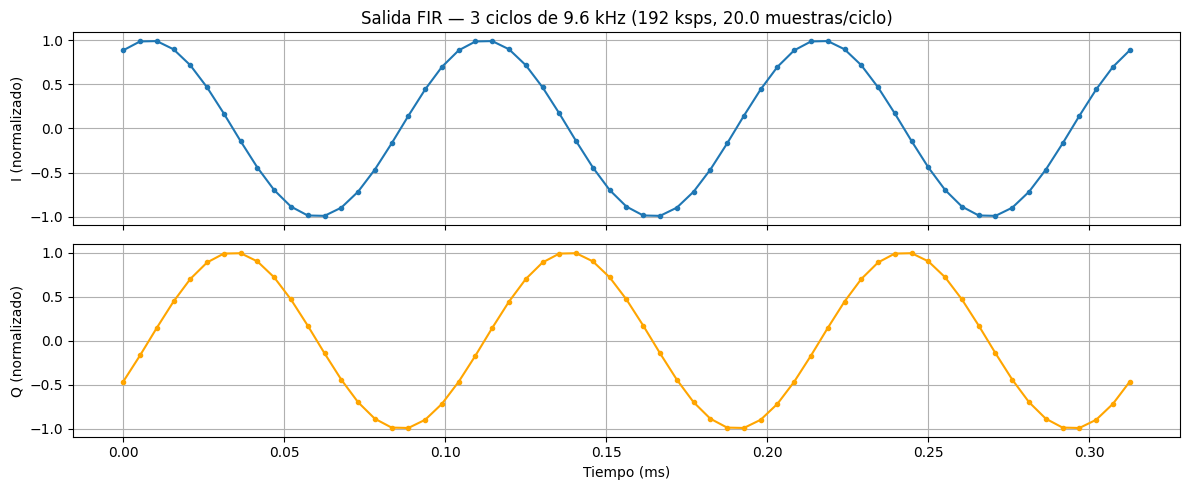

Pico en: 9.61 kHz (esperado: 9.6 kHz)


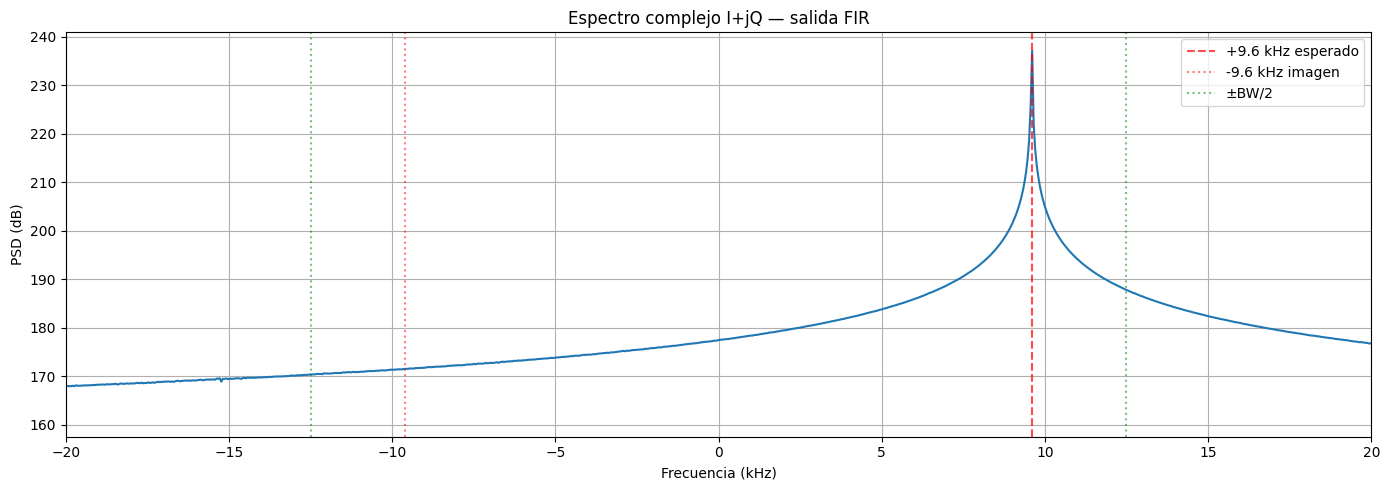

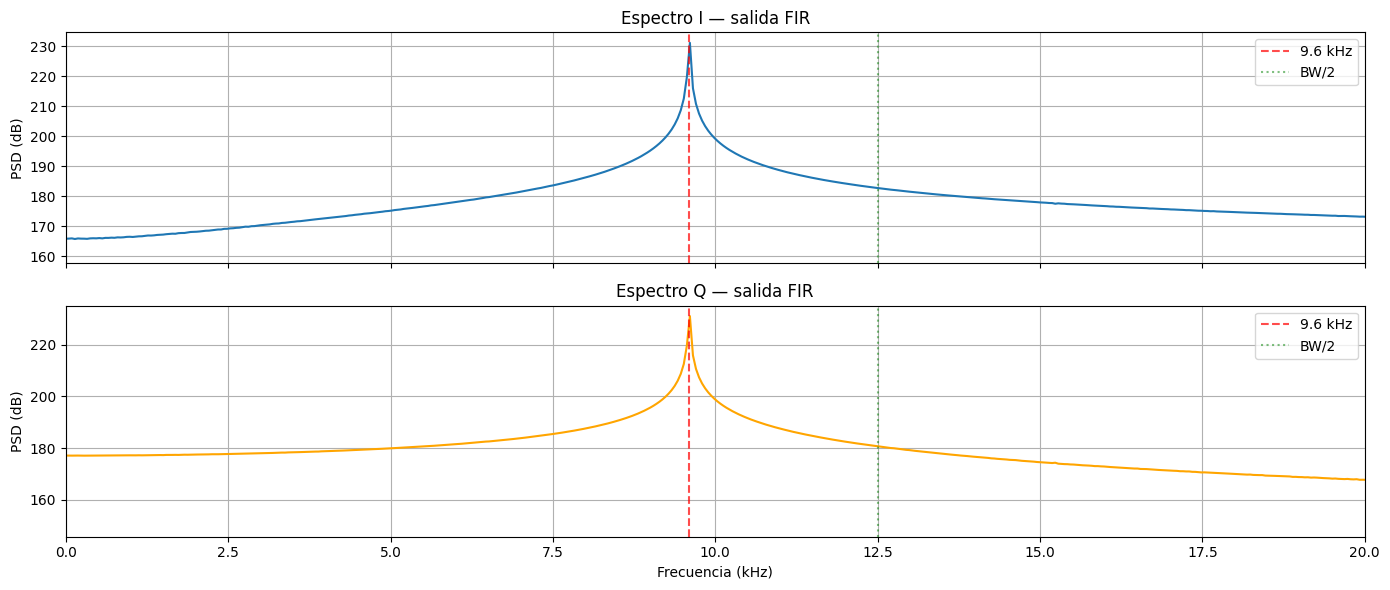

Listo.


In [12]:
import socket
import struct
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.19.216.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05

fs_out   = 125e6/651
f_lo_hz  = 10.7e6
f_offset = 9.6e3

# Rango de visualización espectro
f_min_khz = -20.0
f_max_khz =  20.0

PINC = round(f_lo_hz / 125e6 * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

print(f"PINC = {PINC}")
print(f"CFG_VAL_RUN = 0x{CFG_VAL_RUN:08X}")
print(f"fs_out = {fs_out:.0f} sps")
print(f"Muestras/símbolo a 9600 bps: {fs_out/9600:.2f}")

def send_cmd(sock, cmd, payload):
    sock.sendall(struct.pack('B', cmd))
    sock.sendall(struct.pack('I', payload))

def read_ack(sock):
    data = sock.recv(1)
    print(f"  ACK: 0x{data[0]:02X}")
    return data[0] == 0x01

def read_adc(sock, n_samples):
    """
    FIR con Number_Channels=2 entrega I y Q alternados, cada uno 32 bits.
    n_samples muestras complejas = n_samples*2 palabras de 32 bits.
    El servidor cuenta palabras de 32 bits → pedimos n_samples*2.
    El FIFO tiene 4096 palabras de 64 bits = 4096 pares I/Q → max n_samples=4096.
    """
    n_words = n_samples * 2

    print("Reseteando FIFO...")
    send_cmd(sock, CMD_SET_FIFO, 0)
    read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1)
    read_ack(sock)

    print(f"Pidiendo {n_samples} muestras complejas ({n_words*4} bytes)...")
    send_cmd(sock, CMD_READ_ADC, n_words)

    raw = b''
    total = n_words * 4
    while len(raw) < total:
        chunk = sock.recv(total - len(raw))
        raw += chunk
        print(f"  {len(raw)}/{total} bytes")

    # int32 con signo — salida del FIR de 32 bits
    words = struct.unpack(f'{n_words}i', raw)
    I_bb = np.array(words[0::2], dtype=float)  # palabras pares = I
    Q_bb = np.array(words[1::2], dtype=float)  # palabras impares = Q
    return I_bb, Q_bb

sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
print("Conectado.")

send_cmd(sock, CMD_SET_CFG, CFG_VAL_RESET)
read_ack(sock)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RUN)
read_ack(sock)

n_samples = 4096
I_bb, Q_bb = read_adc(sock, n_samples)
sock.close()

t = np.arange(n_samples) / fs_out * 1e3  # ms

# Dominio temporal — 3 ciclos
n_ciclos = 3
t_max = n_ciclos / f_offset * 1e3
mask_t = t < t_max
muestras_por_ciclo = fs_out / f_offset

I_norm = I_bb / (np.max(np.abs(I_bb)) + 1e-10)
Q_norm = Q_bb / (np.max(np.abs(Q_bb)) + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t[mask_t], I_norm[mask_t], 'o-', markersize=3)
ax1.set_ylabel('I (normalizado)')
ax1.set_title(f'Salida FIR — {n_ciclos} ciclos de {f_offset/1e3:.1f} kHz '
              f'({fs_out/1e3:.0f} ksps, {muestras_por_ciclo:.1f} muestras/ciclo)')
ax1.grid(True)

ax2.plot(t[mask_t], Q_norm[mask_t], 'o-', markersize=3, color='orange')
ax2.set_ylabel('Q (normalizado)')
ax2.set_xlabel('Tiempo (ms)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Espectro complejo bilateral con ventana Blackman
S     = np.fft.fftshift(np.fft.fft((I_bb + 1j * Q_bb)))
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1/fs_out))
Pxx   = 10 * np.log10(np.abs(S)**2 + 1e-20)

freq_peak = freqs[np.argmax(Pxx)]
print(f"Pico en: {freq_peak/1e3:.2f} kHz (esperado: {f_offset/1e3:.1f} kHz)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs/1e3, Pxx)
ax.axvline( f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'+{f_offset/1e3:.1f} kHz esperado')
ax.axvline(-f_offset/1e3, color='r', linestyle=':', alpha=0.5,
            label=f'-{f_offset/1e3:.1f} kHz imagen')
ax.axvline( 12.5, color='g', linestyle=':', alpha=0.5, label='±BW/2')
ax.axvline(-12.5, color='g', linestyle=':', alpha=0.5)
ax.set_xlabel('Frecuencia (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title('Espectro complejo I+jQ — salida FIR')
ax.set_xlim(f_min_khz, f_max_khz)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

# Espectro I y Q por separado
Pxx_I   = 10 * np.log10(np.abs(np.fft.rfft(I_bb))**2 + 1e-20)
Pxx_Q   = 10 * np.log10(np.abs(np.fft.rfft(Q_bb))**2 + 1e-20)
freqs_r = np.fft.rfftfreq(n_samples, d=1/fs_out)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(freqs_r/1e3, Pxx_I)
ax1.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax1.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax1.set_ylabel('PSD (dB)'); ax1.set_title('Espectro I — salida FIR')
ax1.set_xlim(0, f_max_khz); ax1.legend(); ax1.grid(True)

ax2.plot(freqs_r/1e3, Pxx_Q, color='orange')
ax2.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax2.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax2.set_ylabel('PSD (dB)'); ax2.set_xlabel('Frecuencia (kHz)')
ax2.set_title('Espectro Q — salida FIR')
ax2.set_xlim(0, f_max_khz); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

print("Listo.")

Centro del barrido (LO)   : 10.7000 MHz
Tono TX fijo (autonomo)   : 10.709600 MHz (offset +9.6 kHz)
Ancho del barrido         : 180 kHz, paso 2.0 kHz
Conectado.

Barriendo 91 puntos...
  Offset (kHz)    f_LO (MHz)   Potencia (dB)
         -90.0       10.6100            84.9
         -88.0       10.6120            85.1
         -86.0       10.6140            85.3
         -84.0       10.6160            85.1
         -82.0       10.6180            85.7
         -80.0       10.6200            85.4
         -78.0       10.6220            85.4
         -76.0       10.6240            85.6
         -74.0       10.6260            85.5
         -72.0       10.6280            85.6
         -70.0       10.6300            85.8
         -68.0       10.6320            85.7
         -66.0       10.6340            87.4
         -64.0       10.6360           103.1
         -62.0       10.6380           116.7
         -60.0       10.6400           126.0
         -58.0       10.6420           132.5
     

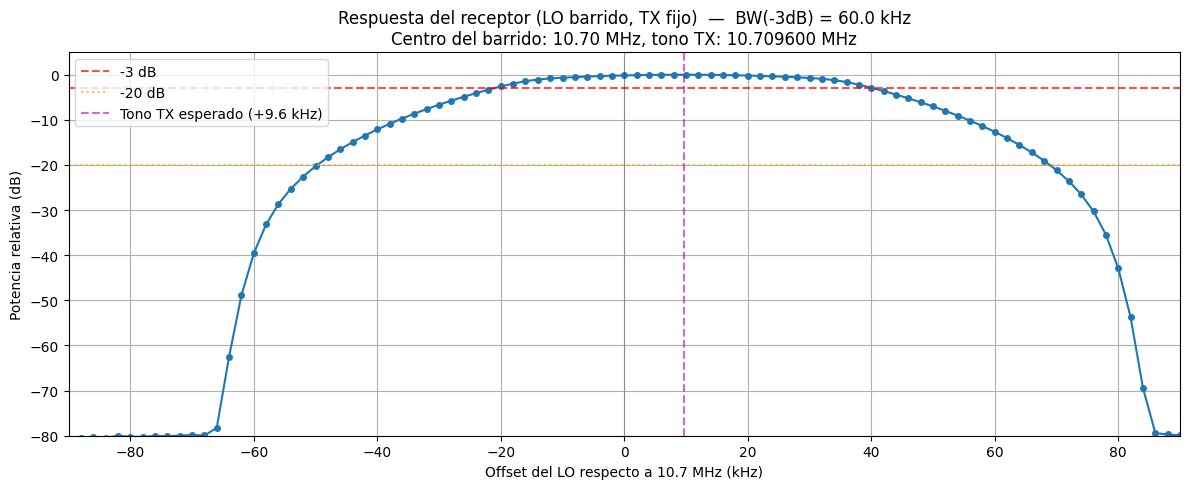

Listo.


In [1]:
"""
Barrido en frecuencia del LO del receptor (osc_0), con el TX corriendo
de forma AUTONOMA: un dds_compiler de frecuencia fija a 10.7 MHz + 9.6 kHz
conectado directo al DAC (sin PS, sin FIFO, sin CMD_TX_*).

No hay control de TX desde este cliente -- el tono de prueba ya esta
saliendo por el DAC de forma continua en cuanto el bitstream corre.

Metodo:
  1. Barrer el PINC del LO (osc_0, RX) en un rango centrado en 10.7 MHz
  2. En cada paso, resetear el FIFO RX y capturar IQ
  3. Medir la potencia total (sin ventana, sin FFT) = mean(|I+jQ|^2)
  4. Graficar potencia vs offset del LO respecto a 10.7 MHz

Como el tono TX esta fijo en 10.7 MHz + 9.6 kHz, el pico de potencia
deberia aparecer cuando el LO barrido pasa por esa frecuencia, es decir
en offset = +9.6 kHz respecto al centro del barrido (10.7 MHz).
"""

import socket
import struct
import time
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.19.216.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05

FS = 125e6

f_lo_centro = 10.7e6      # centro del barrido
f_tono_tx   = 10.7e6 + 9.6e3   # frecuencia fija del tono TX (autonomo)

SWEEP_BW   = 180e3        # ancho total del barrido
SWEEP_STEP = 2e3          # paso del barrido
N_SAMPLES  = 4096         # muestras complejas por punto

def send_cmd(sock, cmd, payload):
    sock.sendall(struct.pack('B', cmd))
    sock.sendall(struct.pack('I', payload))

def read_ack(sock):
    data = sock.recv(1)
    return data[0] == 0x01

def set_lo(sock, f_lo_hz):
    """Configura el PINC del LO (osc_0, receptor) sin tocar el bit de reset."""
    PINC = round(f_lo_hz / FS * (1 << 30))
    cfg_val = (PINC << 1) | 1    # bit 0 = run
    send_cmd(sock, CMD_SET_CFG, cfg_val)
    read_ack(sock)
    return PINC

def capturar_iq(sock, n_samples):
    n_words = n_samples * 2
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''
    total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    words = struct.unpack(f'{n_words}i', raw)
    I_bb = np.array(words[0::2], dtype=float)
    Q_bb = np.array(words[1::2], dtype=float)
    return I_bb + 1j * Q_bb

def medir_potencia(iq):
    """Potencia total, sin ventana ni FFT: mean(|I+jQ|^2)."""
    return 10 * np.log10(np.mean(np.abs(iq)**2) + 1e-20)

# ============================================================
# FLUJO PRINCIPAL
# ============================================================
print(f"Centro del barrido (LO)   : {f_lo_centro/1e6:.4f} MHz")
print(f"Tono TX fijo (autonomo)   : {f_tono_tx/1e6:.6f} MHz (offset +{(f_tono_tx-f_lo_centro)/1e3:.1f} kHz)")
print(f"Ancho del barrido         : {SWEEP_BW/1e3:.0f} kHz, paso {SWEEP_STEP/1e3:.1f} kHz")

sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
print("Conectado.")

offsets = np.arange(-SWEEP_BW/2, SWEEP_BW/2 + SWEEP_STEP, SWEEP_STEP)
potencias = []

print(f"\nBarriendo {len(offsets)} puntos...")
print(f"{'Offset (kHz)':>14}  {'f_LO (MHz)':>12}  {'Potencia (dB)':>14}")

for offset in offsets:
    f_lo = f_lo_centro + offset
    set_lo(sock, f_lo)
    time.sleep(0.03)

    iq = capturar_iq(sock, N_SAMPLES)
    pwr = medir_potencia(iq)
    potencias.append(pwr)
    print(f"{offset/1e3:>14.1f}  {f_lo/1e6:>12.4f}  {pwr:>14.1f}")

# restaurar LO al centro
set_lo(sock, f_lo_centro)
sock.close()

potencias = np.array(potencias)
offsets_khz = offsets / 1e3

pmax = potencias.max()
potencias_norm = potencias - pmax
offset_pico = offsets_khz[np.argmax(potencias)]

mask_3db = potencias_norm >= -3.0
if mask_3db.any():
    bw_3db = (offsets[mask_3db].max() - offsets[mask_3db].min()) / 1e3
    print(f"\nAncho de banda a -3 dB: {bw_3db:.1f} kHz")
    print(f"Pico en offset: {offset_pico:.1f} kHz (esperado: +{(f_tono_tx-f_lo_centro)/1e3:.1f} kHz)")
else:
    bw_3db = None
    print("\nNo se pudo determinar el BW a -3 dB")

# ============================================================
# GRAFICA
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(offsets_khz, potencias_norm, 'o-', markersize=4)
ax.axhline(-3,  color='r', ls='--', alpha=0.7, label='-3 dB')
ax.axhline(-20, color='orange', ls=':', alpha=0.7, label='-20 dB')
ax.axvline((f_tono_tx - f_lo_centro)/1e3, color='m', ls='--', alpha=0.6,
           label=f'Tono TX esperado (+{(f_tono_tx-f_lo_centro)/1e3:.1f} kHz)')
ax.axvline(0, color='k', ls='-', alpha=0.2, lw=0.8)
if bw_3db:
    ax.set_title(f'Respuesta del receptor (LO barrido, TX fijo)  —  BW(-3dB) = {bw_3db:.1f} kHz\n'
                 f'Centro del barrido: {f_lo_centro/1e6:.2f} MHz, tono TX: {f_tono_tx/1e6:.6f} MHz')
else:
    ax.set_title(f'Respuesta del receptor (LO barrido, TX fijo)\n'
                 f'Centro del barrido: {f_lo_centro/1e6:.2f} MHz, tono TX: {f_tono_tx/1e6:.6f} MHz')
ax.set_xlabel('Offset del LO respecto a 10.7 MHz (kHz)')
ax.set_ylabel('Potencia relativa (dB)')
ax.set_xlim(offsets_khz.min(), offsets_khz.max())
ax.set_ylim(-80, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('sweep_lo_tx_fijo.png', dpi=110)
print("Grafica -> sweep_lo_tx_fijo.png")
plt.show()

print("Listo.")